<a href="https://colab.research.google.com/github/Prasannabade13/HEOR-Healthcare-Economics-and-Outcomes-Research-/blob/main/HEOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


STEP 1 Data Collection

In [10]:
df = pd.read_csv("/content/hospital_patient_treatment_dataset.csv")

In [11]:
df.head()


,Patient ID,Department,Treatment Type,Doctor Name,Gender,Age,Treatment Cost,Hospital Stay (Days),Recovery Score
0,P1001,Gastroenterology,Therapy,Dr. L. Khan,Female,12,68632.97,21,82
1,P1002,Pediatrics,Medication,Dr. M. Patel,Male,52,10231.42,20,42
2,P1003,Pediatrics,Therapy,Dr. L. Khan,Male,79,10160.24,2,72
3,P1004,Pediatrics,Therapy,Dr. L. Khan,Female,23,103508.96,20,50
4,P1005,Orthopedics,Medication,Dr. T. Mehta,Female,7,143427.52,6,43


In [12]:
df.shape

(200, 9)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Patient ID            200 non-null    object 
 1   Department            200 non-null    object 
 2   Treatment Type        200 non-null    object 
 3   Doctor Name           200 non-null    object 
 4   Gender                200 non-null    object 
 5   Age                   200 non-null    int64  
 6   Treatment Cost        200 non-null    float64
 7   Hospital Stay (Days)  200 non-null    int64  
 8   Recovery Score        200 non-null    int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 14.2+ KB


STEP 2 Data Cleaning & Preprocessing

In [14]:
df.isnull().sum()

,0
Patient ID,0
Department,0
Treatment Type,0
Doctor Name,0
Gender,0
Age,0
Treatment Cost,0
Hospital Stay (Days),0
Recovery Score,0


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.dtypes


,0
Patient ID,object
Department,object
Treatment Type,object
Doctor Name,object
Gender,object
Age,int64
Treatment Cost,float64
Hospital Stay (Days),int64
Recovery Score,int64


In [17]:
df["calculated_cost_per_day"]=df["Treatment Cost"]/df["Hospital Stay (Days)"]

In [18]:
df[["calculated_cost_per_day"]].head()

,calculated_cost_per_day
0,3268.236667
1,511.571000
2,5080.120000
3,5175.448000
4,23904.586667


In [19]:
df[["Treatment Cost", "Hospital Stay (Days)", "calculated_cost_per_day"]].describe()

,Treatment Cost,Hospital Stay (Days),calculated_cost_per_day
count,200.000000,200.000000,200.000000
mean,79698.513500,16.015000,10035.431556
std,43406.740591,9.109318,17292.321772
min,5444.800000,1.000000,276.102000
25%,45451.882500,7.000000,3055.217187
50%,79268.870000,17.000000,4996.367946
75%,118701.897500,24.000000,10083.238864
max,149340.160000,30.000000,143381.070000


In [20]:
df.shape


(200, 10)

STEP 3 Exploratory Data Analysis

Basic Dataset Overview

In [21]:
df.describe()


,Age,Treatment Cost,Hospital Stay (Days),Recovery Score,calculated_cost_per_day
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,41.710000,79698.513500,16.015000,70.375000,10035.431556
std,26.136978,43406.740591,9.109318,17.726407,17292.321772
min,1.000000,5444.800000,1.000000,40.000000,276.102000
25%,19.000000,45451.882500,7.000000,55.000000,3055.217187
50%,40.000000,79268.870000,17.000000,72.000000,4996.367946
75%,62.250000,118701.897500,24.000000,85.000000,10083.238864
max,90.000000,149340.160000,30.000000,100.000000,143381.070000


Patient Demographics Analysis

In [22]:
df["Age"].describe()


,Age
count,200.000000
mean,41.710000
std,26.136978
min,1.000000
25%,19.000000
50%,40.000000
75%,62.250000
max,90.000000


Department Wise Analysis

In [23]:
dept_summary = df.groupby("Department").agg({
    "Treatment Cost": "mean",
    "Hospital Stay (Days)": "mean",
    "Recovery Score": "mean"
}).round(2)

dept_summary


,Treatment Cost,Hospital Stay (Days),Recovery Score
Department,,,
Cardiology,75039.26,15.83,70.50
Gastroenterology,72489.53,15.61,71.80
Neurology,75960.44,15.18,66.39
Oncology,89613.51,16.94,72.42
Orthopedics,89613.62,15.63,67.26
Pediatrics,75170.03,16.82,73.13


Treatment Type Analysis

In [24]:
treatment_summary = df.groupby("Treatment Type").agg({
    "Treatment Cost": "mean",
    "Hospital Stay (Days)": "mean",
    "Recovery Score": "mean"
}).round(2)

treatment_summary

,Treatment Cost,Hospital Stay (Days),Recovery Score
Treatment Type,,,
Medication,80753.25,15.44,67.58
Observation,78660.43,16.51,70.02
Surgery,83729.88,15.21,73.29
Therapy,75643.99,16.96,70.98


Cost VS Outcome Relationship

In [25]:
df[["Treatment Cost", "Recovery Score"]].corr()


,Treatment Cost,Recovery Score
Treatment Cost,1.000000,0.088918
Recovery Score,0.088918,1.000000


Hospital Stay Impact on Cost

In [26]:
df[["Hospital Stay (Days)", "Treatment Cost"]].corr()


,Hospital Stay (Days),Treatment Cost
Hospital Stay (Days),1.00000,0.07626
Treatment Cost,0.07626,1.00000


Cost Efficiency Evaluation


In [27]:
df["Cost Efficiency Score"] = df["Recovery Score"] / df["calculated_cost_per_day"]
df.sort_values(
    by="Cost Efficiency Score",
    ascending=False
).head(10)

,Patient ID,Department,Treatment Type,Doctor Name,Gender,Age,Treatment Cost,Hospital Stay (Days),Recovery Score,calculated_cost_per_day,Cost Efficiency Score
153,P1154,Gastroenterology,Medication,Dr. A. Sharma,Other,28,5522.04,20,95,276.102000,0.344076
39,P1040,Pediatrics,Surgery,Dr. T. Mehta,Male,14,9067.38,28,86,323.835000,0.265567
155,P1156,Gastroenterology,Surgery,Dr. R. Singh,Female,2,14606.74,30,75,486.891333,0.154038
196,P1197,Orthopedics,Observation,Dr. L. Khan,Female,8,7805.22,13,91,600.401538,0.151565
148,P1149,Pediatrics,Therapy,Dr. R. Singh,Female,78,15165.98,25,86,606.639200,0.141765
82,P1083,Cardiology,Therapy,Dr. T. Mehta,Female,71,11066.61,17,86,650.977059,0.132109
174,P1175,Gastroenterology,Surgery,Dr. M. Patel,Male,11,18263.25,29,83,629.767241,0.131795
178,P1179,Oncology,Observation,Dr. L. Khan,Male,82,19213.51,26,96,738.981154,0.129909
72,P1073,Neurology,Observation,Dr. L. Khan,Other,62,16296.15,28,63,582.005357,0.108246
116,P1117,Gastroenterology,Medication,Dr. M. Patel,Male,14,10917.19,22,43,496.235909,0.086652


STEP 4 KPI Identification & Calculation

Calculating overall Economic KPIs

KPI 1 Average Treatment Cost

In [28]:
avg_treatment_cost = df["Treatment Cost"].mean()
avg_treatment_cost


np.float64(79698.5135)

KPI 2 Average Length of Stay

In [29]:
avg_los = df["Hospital Stay (Days)"].mean()
avg_los


np.float64(16.015)

KPI 3 Average Cost Per Day

In [30]:
avg_cost_per_day = df["calculated_cost_per_day"].mean()
avg_cost_per_day

np.float64(10035.43155550783)

Calculating All Clinical KPIs

Average Recovery Score

In [31]:
avg_recovery_score = df["Recovery Score"].mean()
avg_recovery_score


np.float64(70.375)

Recovery Per Day

In [32]:
df["Recovery Per Day"] = df["Recovery Score"] / df["Hospital Stay (Days)"]


In [33]:
df[["Recovery Score", "Hospital Stay (Days)", "Recovery Per Day"]].head(6)


,Recovery Score,Hospital Stay (Days),Recovery Per Day
0,82,21,3.904762
1,42,20,2.100000
2,72,2,36.000000
3,50,20,2.500000
4,43,6,7.166667
5,41,9,4.555556


Average Recovery Per Day


In [34]:
avg_recovery_per_day = df["Recovery Per Day"].mean()
avg_recovery_per_day


np.float64(9.296977596796578)

Calculating All Operational KPIs

Department-Wise Average Cost

In [35]:
dept_avg_cost = df.groupby("Department")["Treatment Cost"].mean()
dept_avg_cost


,Treatment Cost
Department,
Cardiology,75039.257500
Gastroenterology,72489.531220
Neurology,75960.437857
Oncology,89613.507097
Orthopedics,89613.622105
Pediatrics,75170.029474


Treatment-Wise Cost Efficiency

In [36]:
treatment_efficiency = df.groupby("Treatment Type")["Cost Efficiency Score"].mean()
treatment_efficiency


,Cost Efficiency Score
Treatment Type,
Medication,0.024806
Observation,0.024353
Surgery,0.028113
Therapy,0.023952


Gender Wise Recovery Score

In [37]:
gender_recovery = df.groupby("Gender")["Recovery Score"].mean()
gender_recovery


,Recovery Score
Gender,
Female,71.614035
Male,72.283951
Other,66.741935


KPI Summary Table

In [38]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Average Treatment Cost",
        "Average Length of Stay",
        "Average Cost Per Day",
        "Average Recovery Score",
        "Average Recovery Per Day"
    ],
    "Value": [
        avg_treatment_cost,
        avg_los,
        avg_cost_per_day,
        avg_recovery_score,
        avg_recovery_per_day
    ]
})

kpi_summary


,KPI,Value
0,Average Treatment Cost,79698.513500
1,Average Length of Stay,16.015000
2,Average Cost Per Day,10035.431556
3,Average Recovery Score,70.375000
4,Average Recovery Per Day,9.296978


STEP 5 Statistical Analysis

In [39]:
df[["Treatment Cost", "Hospital Stay (Days)", "Recovery Score", "Recovery Per Day"]].head()


,Treatment Cost,Hospital Stay (Days),Recovery Score,Recovery Per Day
0,68632.97,21,82,3.904762
1,10231.42,20,42,2.100000
2,10160.24,2,72,36.000000
3,103508.96,20,50,2.500000
4,143427.52,6,43,7.166667


Correlation Analysis

1. Cost vs Recovery Score

In [40]:
cost_recovery_corr = df["Treatment Cost"].corr(df["Recovery Score"])
cost_recovery_corr


np.float64(0.08891781573957899)

2️. Hospital Stay vs Recovery Score

In [41]:
stay_recovery_corr = df["Hospital Stay (Days)"].corr(df["Recovery Score"])
stay_recovery_corr


np.float64(0.12525432920915633)

3. Cost vs Recovery Per Day

In [42]:
cost_efficiency_corr = df["Treatment Cost"].corr(df["Recovery Per Day"])
cost_efficiency_corr


np.float64(-0.09371714009323596)

Summary

In [43]:
stat_summary = {
    "Cost vs Recovery Correlation": cost_recovery_corr,
    "Stay vs Recovery Correlation": stay_recovery_corr,
    "Cost vs Recovery Per Day Correlation": cost_efficiency_corr
}

stat_summary


{'Cost vs Recovery Correlation': np.float64(0.08891781573957899),
 'Stay vs Recovery Correlation': np.float64(0.12525432920915633),
 'Cost vs Recovery Per Day Correlation': np.float64(-0.09371714009323596)}

STEP 6 Visualization

Treatment Cost Distribution

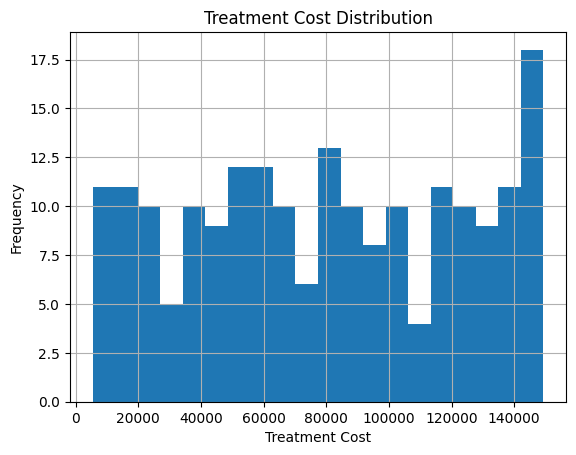

In [44]:
plt.figure()
df["Treatment Cost"].hist(bins=20)
plt.title("Treatment Cost Distribution")
plt.xlabel("Treatment Cost")
plt.ylabel("Frequency")
plt.show()

Department vs Average Treatment Cost

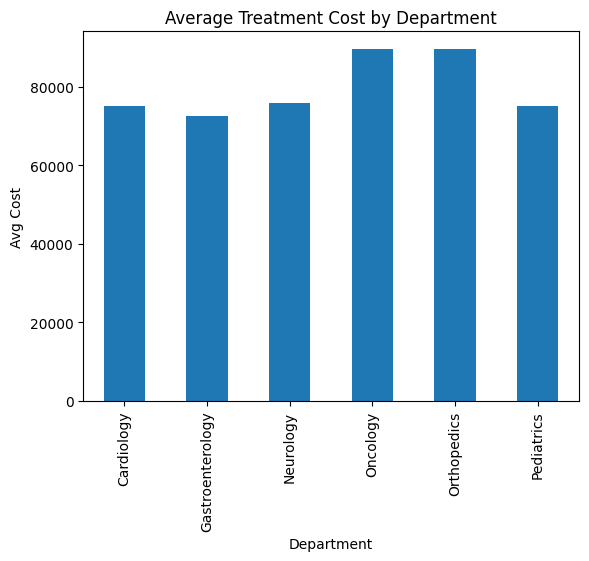

In [45]:
dept_cost = df.groupby("Department")["Treatment Cost"].mean()

plt.figure()
dept_cost.plot(kind="bar")
plt.title("Average Treatment Cost by Department")
plt.xlabel("Department")
plt.ylabel("Avg Cost")
plt.show()


Hospital Stay vs Treatment Cost

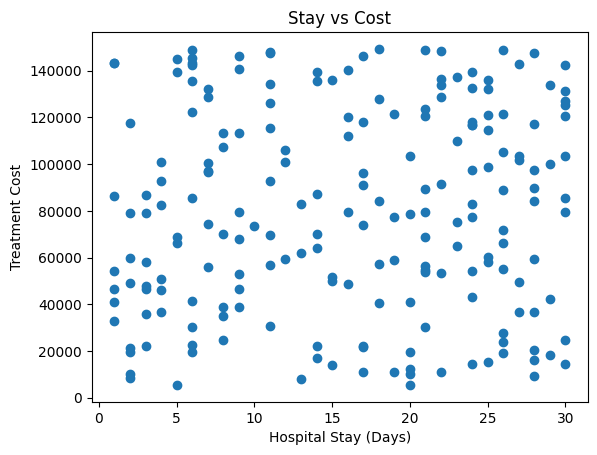

In [46]:
plt.figure()
plt.scatter(df["Hospital Stay (Days)"], df["Treatment Cost"])
plt.xlabel("Hospital Stay (Days)")
plt.ylabel("Treatment Cost")
plt.title("Stay vs Cost")
plt.show()


Recovery Score Distribution

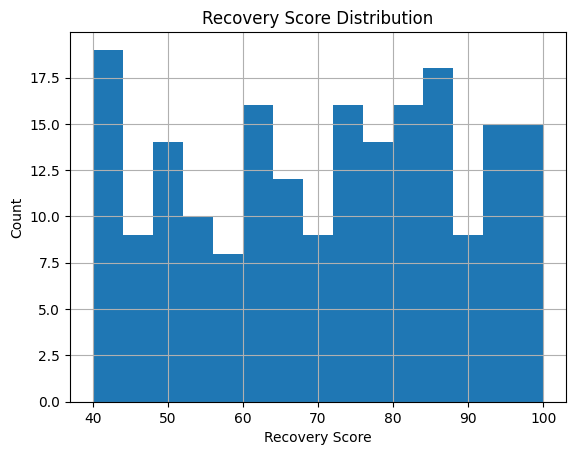

In [47]:
plt.figure()
df["Recovery Score"].hist(bins=15)
plt.title("Recovery Score Distribution")
plt.xlabel("Recovery Score")
plt.ylabel("Count")
plt.show()


Cost Efficiency by Treatment Type

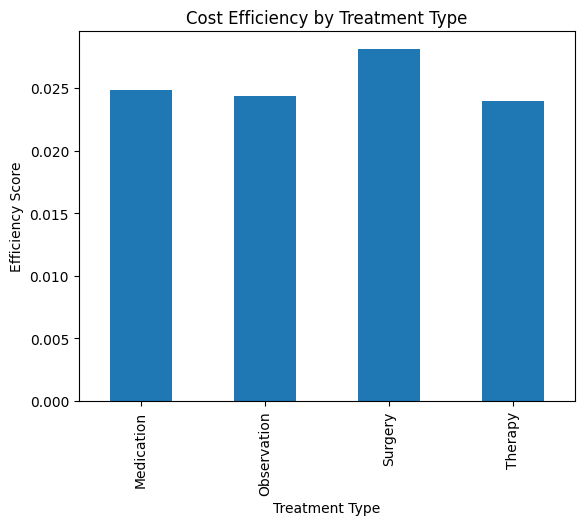

In [48]:
eff = df.groupby("Treatment Type")["Cost Efficiency Score"].mean()

plt.figure()
eff.plot(kind="bar")
plt.title("Cost Efficiency by Treatment Type")
plt.xlabel("Treatment Type")
plt.ylabel("Efficiency Score")
plt.show()


Age vs Recovery Score

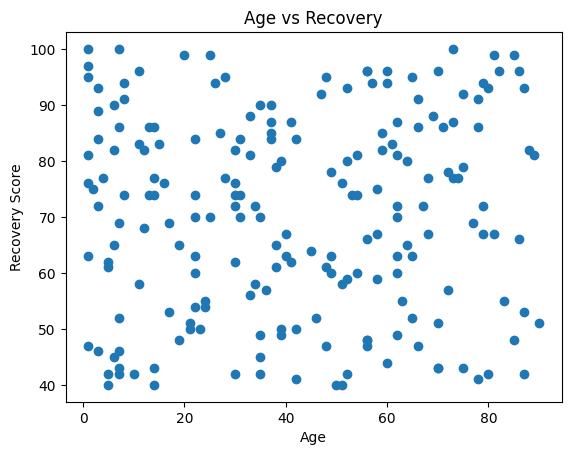

In [49]:
plt.figure()
plt.scatter(df["Age"], df["Recovery Score"])
plt.xlabel("Age")
plt.ylabel("Recovery Score")
plt.title("Age vs Recovery")
plt.show()


Step 7 End To End PreProcessing

Dropping Non-Useful Columns

In [50]:
df_model = df.drop(columns=["Patient ID", "Doctor Name"], errors="ignore")


Separating features & Target

In [51]:
X = df_model.drop("Cost Efficiency Score", axis=1)
y = df_model["Cost Efficiency Score"]


Identifying Column Types

In [52]:
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical:", cat_cols)
print("Numerical:", num_cols)


Categorical: Index(['Department', 'Treatment Type', 'Gender'], dtype='object')
Numerical: Index(['Age', 'Treatment Cost', 'Hospital Stay (Days)', 'Recovery Score',
       'calculated_cost_per_day', 'Recovery Per Day'],
      dtype='object')


Encoding + Scaling with ColumnTransformer

In [53]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer


In [54]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)


Train-Test Split

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Building Full Pipeline

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor())
])


Training Model

In [57]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Treatment Cost', 'Hospital Stay (Days)', 'Recovery Score',
       'calculated_cost_per_day', 'Recovery Per Day'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Department', 'Treatment Type', 'Gender'], dtype='object'))])),
                ('model', RandomForestRegressor())])

Testing the Prediction

In [58]:
preds = pipeline.predict(X_test)


Basic Evaluation

In [59]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2:", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))


R2: 0.9400285080817603
MAE: 0.004945547398349003
